In [1]:
import pandas as pd
%matplotlib inline
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

In [2]:
type(y_train)

pandas.DataFrame

In [3]:
y_train = y_train.squeeze()

In [4]:
type(y_train)

pandas.Series

In [5]:
y_test = y_test.squeeze()

In [6]:
type(X_train)

pandas.DataFrame

In [7]:
X_train.head()

,mths_since_recent_inq,emp_length,num_tl_120dpd_2m,mo_sin_old_il_acct,percent_bc_gt_75,bc_util,bc_open_to_buy,mths_since_recent_bc,revol_util,dti,...,application_type_Joint App,initial_list_status_w,mo_sin_old_il_acct_was_missing,mths_since_recent_bc_was missing,mths_since_recent_inq_was missing,bc_open_to_buy_was missing,bc_util_was missing,percent_bc_gt_75_was missing,num_tl_120dpd_2m_was missing,emp_length_was_missing
0,24.0,5.0,0.0,136.0,33.3,9.6,10485.0,44.0,30.1,12.79,...,False,True,0,0,1,0,0,0,0,0
1,17.0,10.0,0.0,181.0,71.4,67.1,4901.0,13.0,62.2,35.42,...,False,True,0,0,0,0,0,0,0,0
2,4.0,2.0,0.0,136.0,20.0,36.5,26287.0,10.0,27.5,35.23,...,False,True,0,0,0,0,0,0,0,0
3,4.0,7.0,0.0,168.0,10.0,33.0,44548.0,3.0,30.2,5.20,...,False,True,0,0,0,0,0,0,0,0
4,1.0,5.0,0.0,43.0,50.0,65.2,522.0,14.0,43.6,11.00,...,False,True,0,0,0,0,0,0,0,0


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
model = LogisticRegression(class_weight='balanced',max_iter=1000)
scaler = StandardScaler()
scaler.set_output(transform='pandas')
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred_proba  = model.predict_proba(X_test)

In [9]:
X_train.columns.tolist()[:5]

['mths_since_recent_inq',
 'emp_length',
 'num_tl_120dpd_2m',
 'mo_sin_old_il_acct',
 'percent_bc_gt_75']

In [10]:
import numpy as np
np.unique(y_pred,return_counts=True)

(array([0, 1]), array([11023,  6556]))

In [11]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test,y_pred_proba[:,1])
auc

0.7519522622006312

In [12]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test,y_pred)
confusion

array([[9867, 4191],
       [1156, 2365]])

In [13]:
gini = 2*auc-1
gini

0.5039045244012623

In [14]:
from sklearn.metrics import classification_report
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.90      0.70      0.79     14058\n           1       0.36      0.67      0.47      3521\n\n    accuracy                           0.70     17579\n   macro avg       0.63      0.69      0.63     17579\nweighted avg       0.79      0.70      0.72     17579\n'

In [15]:
y_pred

array([1, 0, 0, ..., 0, 1, 1], shape=(17579,))

In [16]:
from scipy.stats import ks_2samp
proba_default = y_pred_proba[y_test == 1, 1]
proba_default

array([0.55146826, 0.20880771, 0.69853991, ..., 0.32941651, 0.71840494,
       0.53743014], shape=(3521,))

In [17]:
proba_no_default = y_pred_proba[y_test == 0,1]
ks_stat, p_value = ks_2samp(proba_default,proba_no_default)

In [18]:
ks_stat

np.float64(0.38025837617022895)

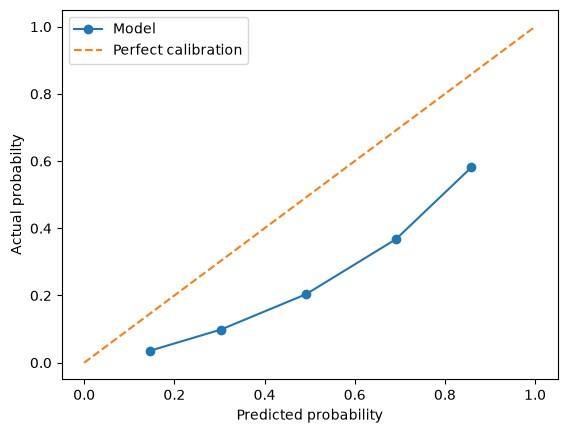

In [19]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
prob_true, prob_pred = calibration_curve(y_test,y_pred_proba[:, 1])
plt.plot(prob_pred,prob_true,marker='o', label='Model')
plt.plot([0,1],[0,1],linestyle="--",label = 'Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Actual probabilty')
plt.legend()
plt.show()

In [20]:
from sklearn.calibration import CalibratedClassifierCV
estimator = LogisticRegression(class_weight='balanced',max_iter=1000)
calibrated_model = CalibratedClassifierCV(estimator=estimator,method = 'sigmoid',cv=5)
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00221D7E84C20>, <sk

In [24]:
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test)

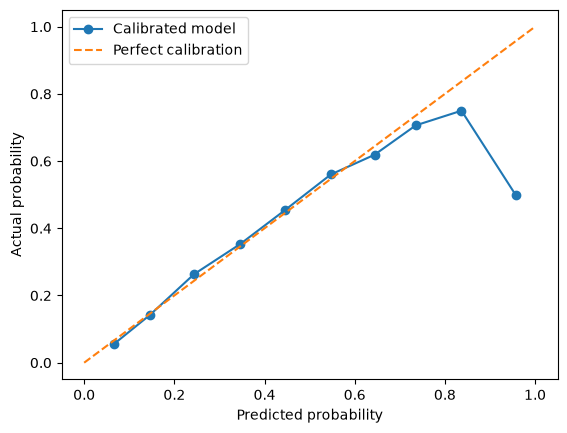

In [26]:
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_calibrated[:, 1], n_bins=10)

plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Actual probability')
plt.legend()
plt.show()

In [32]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(scale_pos_weight = y_train.value_counts()[0]/y_train.value_counts()[1],random_state=123)


In [33]:
X_train_raw = pd.read_csv('../data/X_train.csv')
X_test_raw = pd.read_csv('../data/X_test.csv')
y_train_raw = pd.read_csv('../data/y_train.csv')
y_test_raw = pd.read_csv('../data/y_test.csv')

In [34]:
model_xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)

In [37]:
auc = roc_auc_score(y_test,y_pred_proba_xgb[:,1])
auc

0.7373692321610448

In [39]:
y_pred_proba_xgb_train = model_xgb.predict_proba(X_train)
auc_train = roc_auc_score(y_train,y_pred_proba_xgb_train[:,1])
auc_train

0.8976158918059897

In [43]:
model_xgb = XGBClassifier(
    scale_pos_weight= y_train.value_counts()[0]/y_train.value_counts()[1],  
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)
auc = roc_auc_score(y_test,y_pred_proba_xgb[:,1])
y_pred_proba_xgb_train = model_xgb.predict_proba(X_train)
auc_train = roc_auc_score(y_train,y_pred_proba_xgb_train[:,1])
print(auc)
print(auc_train)

0.7519940515838369
0.7718478438637004


In [44]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.68      0.78     14058
           1       0.35      0.68      0.46      3521

    accuracy                           0.68     17579
   macro avg       0.62      0.68      0.62     17579
weighted avg       0.79      0.68      0.71     17579



In [45]:
confusion_matrix(y_test,y_pred_xgb)

array([[9618, 4440],
       [1112, 2409]])